Checando número de núcleos do processador

In [1]:
import os
print(os.cpu_count())

12


Criando sessão Spark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("eda_taxi").master("local[6]").getOrCreate()

Download da tabela fato com os dados brutos e salvamento em df

In [3]:
import urllib.request
from pathlib import Path

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
destino = Path("data/yellow_tripdata_2024-01.parquet")
destino.parent.mkdir(parents=True, exist_ok=True)

if not destino.exists():
    urllib.request.urlretrieve(url, destino)

df = spark.read.parquet(str(destino))

Avaliar tipo de dado por coluna e número de elemento em df

In [17]:
df.printSchema()
df.show(5, truncate=False)
print("df possui", df.count(), "elementos")

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------

In [26]:
df.columns

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

In [18]:
df.select([F.countDistinct(c).alias(c) for c in df.columns]).show(vertical=True)

-RECORD 0------------------------
 VendorID              | 3       
 tpep_pickup_datetime  | 1575706 
 tpep_dropoff_datetime | 1574780 
 passenger_count       | 10      
 trip_distance         | 4489    
 RatecodeID            | 7       
 store_and_fwd_flag    | 2       
 PULocationID          | 260     
 DOLocationID          | 261     
 payment_type          | 5       
 fare_amount           | 8970    
 extra                 | 48      
 mta_tax               | 8       
 tip_amount            | 4192    
 tolls_amount          | 1127    
 improvement_surcharge | 5       
 total_amount          | 19241   
 congestion_surcharge  | 6       
 Airport_fee           | 3       



## Classificação das colunas — Yellow Taxi

| Coluna | Tipo | Papel na modelagem | Observação |
|---|---|---|---|
| `VendorID` | Categórica (código) | Chave / dimensão | Domínio observado: {1, 2, 6}; tradução via dicionário, sem CSV de apoio |
| `tpep_pickup_datetime` | Temporal | Base da `dim_tempo` | `timestamp_ntz`, sem fuso explícito (hora local de NY presumida) |
| `tpep_dropoff_datetime` | Temporal | Base da `dim_tempo` (role-playing) | Idem |
| `passenger_count` | Numérica discreta | Medida | Informado pelo motorista, não medido por sensor |
| `trip_distance` | Numérica contínua | Medida | Em milhas; relação com valor se solta em tarifas negociadas/Flex Fare |
| `RatecodeID` | Categórica (código) | Chave / dimensão | Nulo estrutural em corridas Flex Fare; inclui código 99 (unknown) |
| `store_and_fwd_flag` | Categórica binária | Atributo (candidata a junk dimension) | Y/N; nulo ligado ao mesmo caso de Flex Fare |
| `PULocationID` | Chave estrangeira | Chave / dimensão (role-playing) | Traduzida via `taxi_zone_lookup.csv` |
| `DOLocationID` | Chave estrangeira | Chave / dimensão (role-playing) | Idem |
| `payment_type` | Categórica (código) | Chave / dimensão | Domínio observado: {0, 1, 2, 3, 4} |
| `fare_amount` | Numérica contínua | Medida | Tarifa calculada pelo taxímetro |
| `extra` | Numérica contínua | Medida | Extras e sobretaxas diversas |
| `mta_tax` | Numérica contínua | Medida | Fixa (0.50), condicionada ao destino |
| `tip_amount` | Numérica contínua | Medida | Só registra gorjeta em cartão |
| `tolls_amount` | Numérica contínua | Medida | Pedágios pagos na viagem |
| `improvement_surcharge` | Numérica contínua | Medida | Fixa (1.00), incondicional |
| `congestion_surcharge` | Numérica contínua | Medida | Condicionada geograficamente (Manhattan abaixo da rua 96) |
| `Airport_fee` | Numérica contínua | Medida | Fixa (1.75 no recorte), condicionada a embarque em aeroporto |
| `total_amount` | Numérica contínua | Medida derivada | Soma verificada dos oito componentes financeiros acima |

**Sem identificador de corrida**: a base não possui coluna de ID único por viagem.

In [23]:
from pyspark.sql import functions as F

monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
              "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee"]

def gerar_histograma_spark(coluna, largura):
    resultado = (df
        .withColumn("faixa", (F.col(coluna) / largura).cast("int") * largura)
        .groupBy("faixa")
        .count()
        .orderBy("faixa"))
    return resultado.toPandas()

larguras = {
    "fare_amount": 5,
    "extra": 0.5,
    "mta_tax": 0.1,
    "tip_amount": 1,
    "tolls_amount": 2,
    "improvement_surcharge": 0.1,
    "total_amount": 5,
    "congestion_surcharge": 0.5,
    "Airport_fee": 0.25,
}

resultados = {}
for col, largura in larguras.items():
    print(f"Processando {col}...")
    resultados[col] = gerar_histograma_spark(col, largura)

Processando fare_amount...
Processando extra...
Processando mta_tax...
Processando tip_amount...
Processando tolls_amount...
Processando improvement_surcharge...
Processando total_amount...
Processando congestion_surcharge...
Processando Airport_fee...


In [25]:
resultado = df.select([
    F.min(c).alias("minimo") for c in monetarias
])

# Ou, de forma mais legível, uma linha por coluna monetária:
from functools import reduce

min_max = reduce(lambda a, b: a.union(b), [
    df.select(
        F.lit(c).alias("coluna"),
        F.min(c).alias("minimo"),
        F.max(c).alias("maximo")
    ) for c in monetarias
])

min_max.show(truncate=False)

+---------------------+------+------+
|coluna               |minimo|maximo|
+---------------------+------+------+
|fare_amount          |-899.0|5000.0|
|extra                |-7.5  |14.25 |
|mta_tax              |-0.5  |4.0   |
|tip_amount           |-80.0 |428.0 |
|tolls_amount         |-80.0 |115.92|
|improvement_surcharge|-1.0  |1.0   |
|total_amount         |-900.0|5000.0|
|congestion_surcharge |-2.5  |2.5   |
|Airport_fee          |-1.75 |1.75  |
+---------------------+------+------+



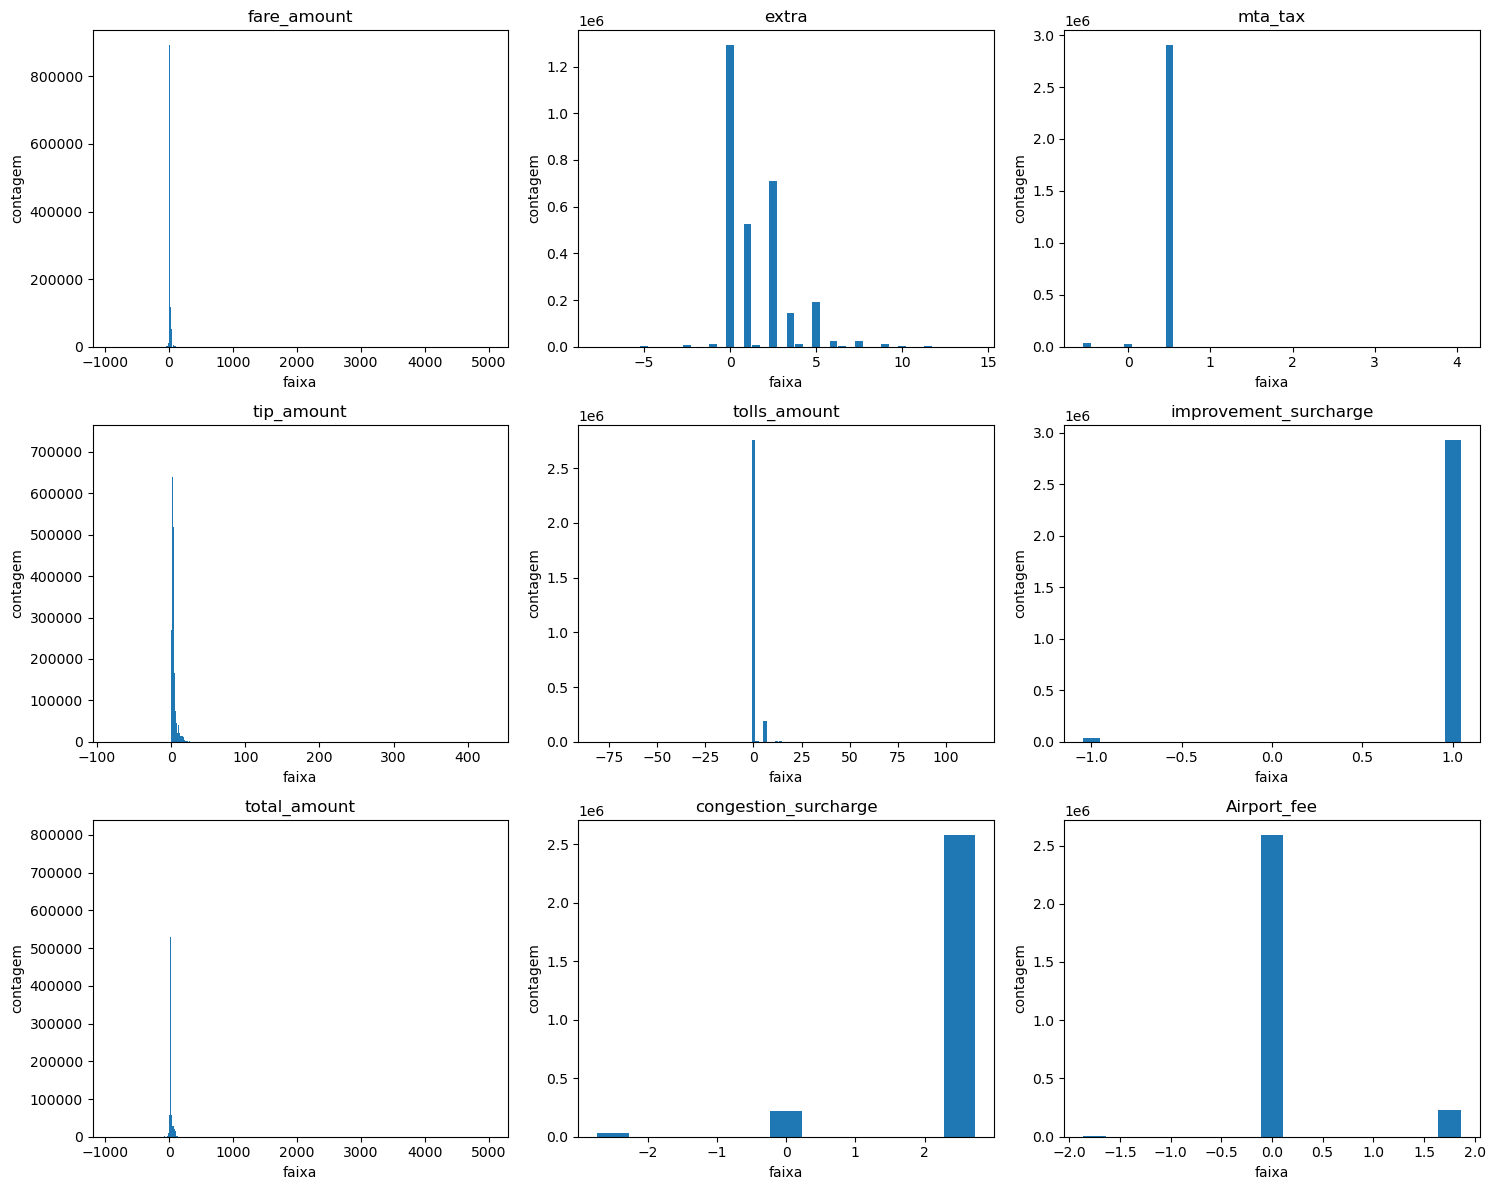

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, (col, pdf) in zip(axes.flatten(), resultados.items()):
    ax.bar(pdf["faixa"], pdf["count"], width=larguras[col]*0.9)
    ax.set_title(col)
    ax.set_xlabel("faixa")
    ax.set_ylabel("contagem")

plt.tight_layout()
plt.show()

## Dicionário de dados — Yellow Taxi Trip Records

Fonte: TLC Trip Record Data (NYC), versão do dicionário de 18/03/2025.
Dicionários de outros tipos de viagem e metadados (como as TLC Taxi Zones):
http://www.nyc.gov/html/tlc/html/about/trip_record_data.shtml

| Coluna | Descrição | Domínio / códigos |
|---|---|---|
| `VendorID` | Código que indica o provedor TPEP que forneceu o registro. | 1 = Creative Mobile Technologies, LLC<br>2 = Curb Mobility, LLC<br>6 = Myle Technologies Inc<br>7 = Helix |
| `tpep_pickup_datetime` | Data e hora em que o taxímetro foi acionado. | — |
| `tpep_dropoff_datetime` | Data e hora em que o taxímetro foi desligado. | — |
| `passenger_count` | Número de passageiros no veículo. | — |
| `trip_distance` | Distância percorrida na viagem, em milhas, reportada pelo taxímetro. | — |
| `RatecodeID` | Código tarifário final vigente ao término da viagem. | 1 = Tarifa padrão<br>2 = JFK<br>3 = Newark<br>4 = Nassau ou Westchester<br>5 = Tarifa negociada<br>6 = Corrida em grupo<br>99 = Nulo/desconhecido |
| `store_and_fwd_flag` | Indica se o registro da viagem ficou retido na memória do veículo antes de ser enviado ao provedor (mecanismo "store and forward"), porque o veículo não tinha conexão com o servidor. | Y = viagem store and forward<br>N = viagem não store and forward |
| `PULocationID` | TLC Taxi Zone na qual o taxímetro foi acionado. | Ver `taxi_zone_lookup.csv` |
| `DOLocationID` | TLC Taxi Zone na qual o taxímetro foi desligado. | Ver `taxi_zone_lookup.csv` |
| `payment_type` | Código numérico que indica como o passageiro pagou pela viagem. | 0 = Viagem Flex Fare<br>1 = Cartão de crédito<br>2 = Dinheiro<br>3 = Sem cobrança<br>4 = Contestada (dispute)<br>5 = Desconhecida<br>6 = Viagem anulada (voided) |
| `fare_amount` | Tarifa por tempo e distância calculada pelo taxímetro. Para informações adicionais sobre as colunas seguintes, ver https://www.nyc.gov/site/tlc/passengers/taxi-fare.page | — |
| `extra` | Extras e sobretaxas diversas. | — |
| `mta_tax` | Taxa acionada automaticamente com base na tarifa metrificada em uso. | — |
| `tip_amount` | Valor da gorjeta. Este campo é preenchido automaticamente para gorjetas em cartão de crédito. **Gorjetas em dinheiro não são incluídas.** | — |
| `tolls_amount` | Valor total de todos os pedágios pagos na viagem. | — |
| `improvement_surcharge` | Sobretaxa de melhoria (improvement surcharge) aplicada às viagens no acionamento do taxímetro (flag drop). Passou a ser cobrada em 2015. | — |
| `total_amount` | Valor total cobrado dos passageiros. **Não inclui gorjetas em dinheiro.** | — |
| `congestion_surcharge` | Valor total arrecadado na viagem referente à sobretaxa de congestionamento do estado de Nova York (NYS). | — |
| `airport_fee` | Aplicada somente em embarques nos aeroportos LaGuardia e John F. Kennedy. | — |
| `cbd_congestion_fee` | Cobrança por viagem referente à Congestion Relief Zone da MTA, **a partir de 05/01/2025**. | Não presente em jan/2024 |

Análise de histograma - variáveis categóricas - pós tratamento

In [21]:
from pyspark.sql import functions as F

monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
              "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee"]

largura = 5  # tamanho de cada faixa, em dólares — ajuste conforme a coluna

def gerar_histograma_spark(coluna, largura, limite_inf=None, limite_sup=None):
    dados = df
    if limite_inf is not None:
        dados = dados.filter(F.col(coluna) >= limite_inf)
    if limite_sup is not None:
        dados = dados.filter(F.col(coluna) <= limite_sup)
    
    resultado = (dados
        .withColumn("faixa", (F.col(coluna) / largura).cast("int") * largura)
        .groupBy("faixa")
        .count()
        .orderBy("faixa"))
    
    return resultado.toPandas()  # já é pequeno aqui — só as faixas, não os dados brutos

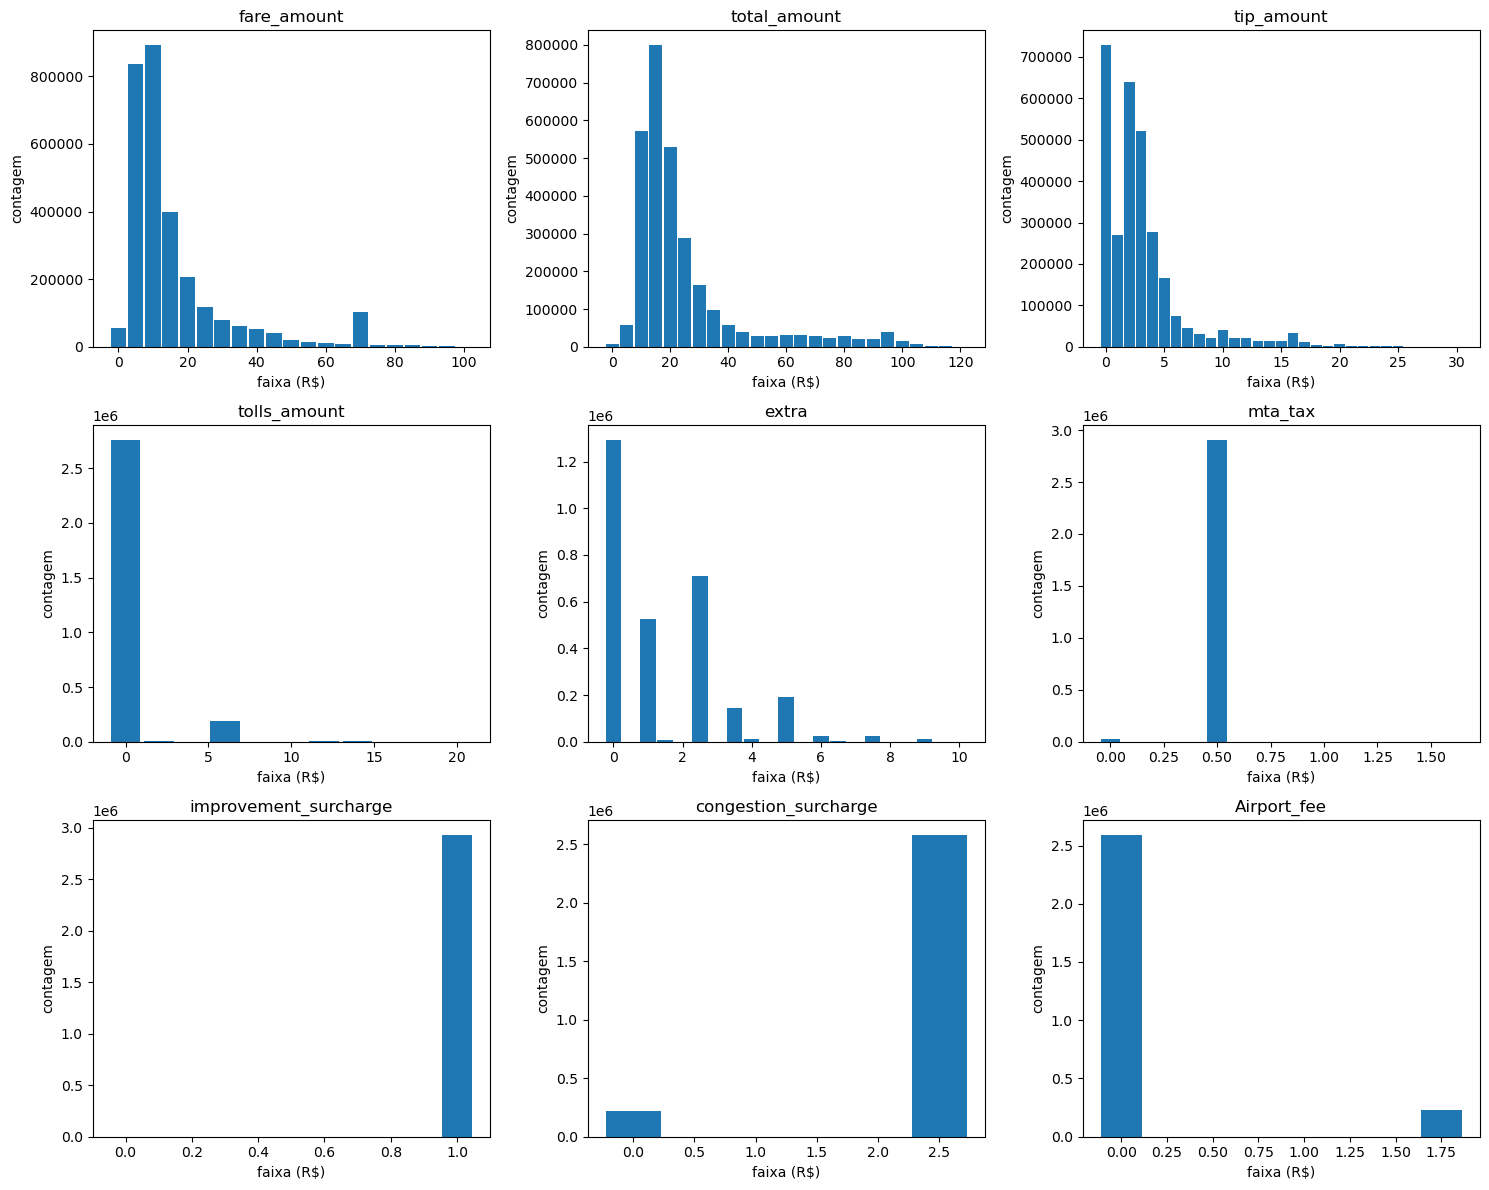

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

configuracoes = {
    "fare_amount": (5, 0, 100),
    "total_amount": (5, 0, 120),
    "tip_amount": (1, 0, 30),
    "tolls_amount": (2, 0, 20),
    "extra": (0.5, 0, 10),
    "mta_tax": (0.1, 0, 2),
    "improvement_surcharge": (0.1, 0, 2),
    "congestion_surcharge": (0.5, 0, 5),
    "Airport_fee": (0.25, 0, 3),
}

for ax, (col, (largura, lim_inf, lim_sup)) in zip(axes.flatten(), configuracoes.items()):
    pdf = gerar_histograma_spark(col, largura, lim_inf, lim_sup)
    ax.bar(pdf["faixa"], pdf["count"], width=largura*0.9)
    ax.set_title(col)
    ax.set_xlabel("faixa (R$)")
    ax.set_ylabel("contagem")

plt.tight_layout()
plt.show()

Verificando linhas duplicadas

In [5]:
from pyspark.sql import functions as F

dups = df.groupBy(df.columns).count().filter(F.col("count") > 1)

dups.count()                              # quantos grupos duplicados existem
dups.orderBy(F.desc("count")).show(10)    # os casos mais repetidos
dups.agg(F.sum("count")).show()           # total de linhas envolvidas

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-----+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|count|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-----+
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----

In [6]:
df.count() - df.dropDuplicates().count()   # deve dar 0

0

A partir da análise acima pode-se aferir que não há nenhum registro duplicado em df. Isso significa que não existem linhas duplicadas na base de dados. Todos os registros são únicos.

Checando a existência de linhas duplicadas para as colunas: "tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID"

In [7]:
chave = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID"]
df.groupBy(chave).count().filter(F.col("count") > 1).count()

31114

Avaliando a presença de valores negativos em 'total_amount'

In [8]:
df_x = df.filter(df.total_amount < 0)
df_x.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|2       |2024-01-01 00:18:24 |2024-01-01 00:30:39  |1              |2.16         |1         |N                 |249         |232         |4           |-13.5      |-1.0 |-0.5   |0.0      

31.114 grupos com repetição, sobre uma base de ~3 milhões de linhas. Se cada grupo tiver 2 viagens, são ~62 mil viagens envolvidas — algo em torno de 2% da base. É pouco em proporção, mas não é ruído desprezível.

In [9]:
nao_monetarias = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", 
                   "DOLocationID", "VendorID", "passenger_count", "trip_distance", 
                   "RatecodeID", "store_and_fwd_flag", "payment_type"]

monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
              "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee"]

neg = df.filter(F.col("total_amount") < 0)
pos = df.filter(F.col("total_amount") >= 0)

# Invertendo o sinal das monetárias do lado negativo, para comparar com o positivo
neg_invertido = neg.select(
    *nao_monetarias,
    *[(-F.col(c)).alias(c) for c in monetarias]
)

# Par = mesmas não-monetárias E monetárias invertidas batendo com o positivo
pares = neg_invertido.join(pos, on=nao_monetarias + monetarias, how="inner")

pares.count()          # quantos negativos têm par exato
neg.count()             # total de negativos

35504

In [11]:
neg.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|2       |2024-01-01 00:18:24 |2024-01-01 00:30:39  |1              |2.16         |1         |N                 |249         |232         |4           |-13.5      |-1.0 |-0.5   |0.0      

In [12]:
neg.count()

35504

In [13]:
pos.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|2       |2024-01-01 00:57:55 |2024-01-01 01:17:43  |1              |1.72         |1         |N                 |186         |79          |2           |17.7       |1.0  |0.5    |0.0      

In [14]:
pos.count()

2929120

In [10]:
neg.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|2       |2024-01-01 00:18:24 |2024-01-01 00:30:39  |1              |2.16         |1         |N                 |249         |232         |4           |-13.5      |-1.0 |-0.5   |0.0      

In [11]:
neg_invertido.show(5, truncate=False)

+--------------------+---------------------+------------+------------+--------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|tpep_pickup_datetime|tpep_dropoff_datetime|PULocationID|DOLocationID|VendorID|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------------------+---------------------+------------+------------+--------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|2024-01-01 00:18:24 |2024-01-01 00:30:39  |249         |232         |2       |1              |2.16         |1         |N                 |4           |13.5       |1.0  |0.5    |-0.0     

In [12]:
nao_monetarias = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", 
                   "DOLocationID", "VendorID", "passenger_count", "trip_distance", 
                   "RatecodeID", "store_and_fwd_flag", "payment_type"]

monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
              "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee"]

todas_colunas = nao_monetarias + monetarias

neg = df.filter(F.col("total_amount") < 0)
pos = df.filter(F.col("total_amount") >= 0)

# Inverte o sinal do lado negativo para comparar com o positivo
neg_invertido = neg.select(
    *nao_monetarias,
    *[(-F.col(c)).alias(c) for c in monetarias]
)

# Quantas linhas negativas existem para cada combinação de valores (já invertidos)
neg_key = neg_invertido.groupBy(todas_colunas).count().withColumnRenamed("count", "n_neg")

# Quantas linhas positivas existem para cada combinação de valores
pos_key = pos.groupBy(todas_colunas).count().withColumnRenamed("count", "n_pos")

# Junta: para cada grupo de negativas, quantas inversas (positivas) existem
comparacao = (neg_key.join(pos_key, on=todas_colunas, how="left")
              .fillna(0, subset=["n_pos"]))

# Distribuição: quantas linhas negativas (n_neg) têm exatamente n_pos inversas
distribuicao = (comparacao.groupBy("n_pos")
                .agg(F.sum("n_neg").alias("qtd_linhas"))
                .withColumnRenamed("n_pos", "numero_de_inversas")
                .orderBy("numero_de_inversas"))

distribuicao.show()

+------------------+----------+
|numero_de_inversas|qtd_linhas|
+------------------+----------+
|                 0|      4835|
|                 1|     30669|
+------------------+----------+



In [13]:
import urllib.request
from pathlib import Path

url_dez_2023 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-12.parquet"
destino_dez = Path("data/yellow_tripdata_2023-12.parquet")
destino_dez.parent.mkdir(parents=True, exist_ok=True)

if not destino_dez.exists():
    urllib.request.urlretrieve(url_dez_2023, destino_dez)

df_dez_2023 = spark.read.parquet(str(destino_dez))

In [14]:
df_dez_2023.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



In [15]:
orfaos_invertidos = neg_invertido.join(pos, on=todas_colunas, how="left_anti")

achados_em_dez = orfaos_invertidos.join(df_dez_2023, on=todas_colunas, how="inner")

achados_em_dez.count()

0

In [16]:
df.crosstab("VendorID", "payment_type").show()

+---------------------+-----+-------+------+-----+-----+
|VendorID_payment_type|    0|      1|     2|    3|    4|
+---------------------+-----+-------+------+-----+-----+
|                    6|  260|      0|     0|    0|    0|
|                    1|48455| 564618|104722| 8120| 3817|
|                    2|91447|1754428|334469|11477|42811|
+---------------------+-----+-------+------+-----+-----+



In [17]:
df.select("VendorID").distinct().orderBy("VendorID").show()
df.select("payment_type").distinct().orderBy("payment_type").show()

+--------+
|VendorID|
+--------+
|       1|
|       2|
|       6|
+--------+

+------------+
|payment_type|
+------------+
|           0|
|           1|
|           2|
|           3|
|           4|
+------------+



In [18]:
vendor_map = {1: "Creative Mobile Technologies", 2: "Curb Mobility", 6: "Myle Technologies"}
payment_map = {0: "Flex Fare", 1: "Credit card", 2: "Cash", 3: "No charge", 4: "Dispute"}

vendor_expr = F.create_map([F.lit(x) for pair in vendor_map.items() for x in pair])
payment_expr = F.create_map([F.lit(x) for pair in payment_map.items() for x in pair])

tabela_nomeada = (df
    .withColumn("vendor_nome", vendor_expr[F.col("VendorID")])
    .withColumn("payment_nome", payment_expr[F.col("payment_type")])
    .groupBy("vendor_nome", "payment_nome")
    .count()
    .groupBy("vendor_nome")
    .pivot("payment_nome")
    .sum("count"))

tabela_nomeada.show()

+--------------------+------+-----------+-------+---------+---------+
|         vendor_nome|  Cash|Credit card|Dispute|Flex Fare|No charge|
+--------------------+------+-----------+-------+---------+---------+
|Creative Mobile T...|104722|     564618|   3817|    48455|     8120|
|       Curb Mobility|334469|    1754428|  42811|    91447|    11477|
|   Myle Technologies|  NULL|       NULL|   NULL|      260|     NULL|
+--------------------+------+-----------+-------+---------+---------+



Checando perfil das linhas com total_amount negativo

In [19]:
categoricas = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]

for col in categoricas:
    print(f"\n=== {col} ===")
    
    total = df.groupBy(col).count().withColumnRenamed("count", "total")
    negativos = neg.groupBy(col).count().withColumnRenamed("count", "negativos")
    
    perfil = (total.join(negativos, on=col, how="left")
                    .fillna(0, subset=["negativos"])
                    .withColumn("fracao_negativa", 
                                F.round(F.col("negativos") / F.col("total") * 100, 2))
                    .orderBy(F.desc("fracao_negativa")))
    
    perfil.show()


=== VendorID ===
+--------+-------+---------+---------------+
|VendorID|  total|negativos|fracao_negativa|
+--------+-------+---------+---------------+
|       2|2234632|    35504|           1.59|
|       1| 729732|        0|            0.0|
|       6|    260|        0|            0.0|
+--------+-------+---------+---------------+


=== RatecodeID ===
+----------+-------+---------+---------------+
|RatecodeID|  total|negativos|fracao_negativa|
+----------+-------+---------+---------------+
|         6|      7|        2|          28.57|
|         3|   7954|      335|           4.21|
|         5|  19410|      721|           3.71|
|         4|   6365|      220|           3.46|
|         2|  98713|     2048|           2.07|
|         1|2663350|    32176|           1.21|
|        99|  28663|        0|            0.0|
|      NULL| 140162|        0|            0.0|
+----------+-------+---------+---------------+


=== payment_type ===
+------------+-------+---------+---------------+
|payment_t

In [20]:
vendor_map = {1: "Creative Mobile Technologies", 2: "Curb Mobility", 6: "Myle Technologies", 7: "Helix"}
rate_map = {1: "Standard rate", 2: "JFK", 3: "Newark", 4: "Nassau/Westchester", 
            5: "Negotiated fare", 6: "Group ride", 99: "Unknown"}
payment_map = {0: "Flex Fare", 1: "Credit card", 2: "Cash", 3: "No charge", 
               4: "Dispute", 5: "Unknown", 6: "Voided trip"}

def cria_map_expr(mapa):
    return F.create_map([F.lit(x) for pair in mapa.items() for x in pair])

df_nomeado = (df
    .withColumn("VendorID_nome", cria_map_expr(vendor_map)[F.col("VendorID")])
    .withColumn("RatecodeID_nome", cria_map_expr(rate_map)[F.col("RatecodeID")])
    .withColumn("payment_type_nome", cria_map_expr(payment_map)[F.col("payment_type")])
)

neg_nomeado = df_nomeado.filter(F.col("total_amount") < 0)

categoricas_nomeadas = ["VendorID_nome", "RatecodeID_nome", "payment_type_nome", "store_and_fwd_flag"]

for col in categoricas_nomeadas:
    print(f"\n=== {col} ===")
    
    total = df_nomeado.groupBy(col).count().withColumnRenamed("count", "total")
    negativos = neg_nomeado.groupBy(col).count().withColumnRenamed("count", "negativos")
    
    perfil = (total.join(negativos, on=col, how="left")
                    .fillna(0, subset=["negativos"])
                    .withColumn("fracao_negativa", 
                                F.round(F.col("negativos") / F.col("total") * 100, 2))
                    .orderBy(F.desc("fracao_negativa")))
    
    perfil.show(truncate=False)


=== VendorID_nome ===
+----------------------------+-------+---------+---------------+
|VendorID_nome               |total  |negativos|fracao_negativa|
+----------------------------+-------+---------+---------------+
|Curb Mobility               |2234632|35504    |1.59           |
|Creative Mobile Technologies|729732 |0        |0.0            |
|Myle Technologies           |260    |0        |0.0            |
+----------------------------+-------+---------+---------------+


=== RatecodeID_nome ===
+------------------+-------+---------+---------------+
|RatecodeID_nome   |total  |negativos|fracao_negativa|
+------------------+-------+---------+---------------+
|Group ride        |7      |2        |28.57          |
|Newark            |7954   |335      |4.21           |
|Negotiated fare   |19410  |721      |3.71           |
|Nassau/Westchester|6365   |220      |3.46           |
|JFK               |98713  |2048     |2.07           |
|Standard rate     |2663350|32176    |1.21           |
|

Todos os negativos são oriundos de Vendor ID = 'Curb Mobility'

In [21]:
df_curb = df_nomeado.filter(F.col("VendorID") == 2)
neg_curb = df_curb.filter(F.col("total_amount") < 0)

categoricas_nomeadas = ["RatecodeID_nome", "payment_type_nome", "store_and_fwd_flag"]

for col in categoricas_nomeadas:
    print(f"\n=== {col} (apenas Curb Mobility) ===")
    
    total = df_curb.groupBy(col).count().withColumnRenamed("count", "total")
    negativos = neg_curb.groupBy(col).count().withColumnRenamed("count", "negativos")
    
    perfil = (total.join(negativos, on=col, how="left")
                    .fillna(0, subset=["negativos"])
                    .withColumn("fracao_negativa", 
                                F.round(F.col("negativos") / F.col("total") * 100, 2))
                    .orderBy(F.desc("fracao_negativa")))
    
    perfil.show(truncate=False)


=== RatecodeID_nome (apenas Curb Mobility) ===
+------------------+-------+---------+---------------+
|RatecodeID_nome   |total  |negativos|fracao_negativa|
+------------------+-------+---------+---------------+
|Group ride        |7      |2        |28.57          |
|Newark            |6381   |335      |5.25           |
|Negotiated fare   |16335  |721      |4.41           |
|Nassau/Westchester|5326   |220      |4.13           |
|JFK               |81698  |2048     |2.51           |
|Standard rate     |2033436|32176    |1.58           |
|Unknown           |2      |0        |0.0            |
|NULL              |91447  |0        |0.0            |
+------------------+-------+---------+---------------+


=== payment_type_nome (apenas Curb Mobility) ===
+-----------------+-------+---------+---------------+
|payment_type_nome|total  |negativos|fracao_negativa|
+-----------------+-------+---------+---------------+
|No charge        |11477  |5741     |50.02          |
|Dispute          |42811 

In [22]:
nao_monetarias = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", 
                   "DOLocationID", "VendorID", "passenger_count", "trip_distance", 
                   "RatecodeID", "store_and_fwd_flag", "payment_type"]

neg = df.filter(F.col("total_amount") < 0)

# Combinações únicas de não-monetárias presentes nos negativos
chaves_neg = neg.select(*nao_monetarias).distinct()

# Quantas linhas no df inteiro batem com cada uma dessas combinações
correspondencias = (df.join(chaves_neg, on=nao_monetarias, how="inner")
                       .groupBy(*nao_monetarias)
                       .count()
                       .withColumnRenamed("count", "total_linhas_iguais"))

correspondencias.orderBy(F.desc("total_linhas_iguais")).show(20, truncate=False)

+--------------------+---------------------+------------+------------+--------+---------------+-------------+----------+------------------+------------+-------------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|PULocationID|DOLocationID|VendorID|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|payment_type|total_linhas_iguais|
+--------------------+---------------------+------------+------------+--------+---------------+-------------+----------+------------------+------------+-------------------+
|2024-01-05 00:46:32 |2024-01-05 01:00:29  |230         |152         |2       |1              |5.95         |1         |N                 |4           |2                  |
|2024-01-10 17:31:53 |2024-01-10 17:52:26  |129         |134         |2       |1              |5.72         |1         |N                 |2           |2                  |
|2024-01-05 12:35:27 |2024-01-05 12:48:16  |186         |163         |2       |1              |1.16         |1         |N              

In [23]:
distribuicao = (correspondencias.groupBy("total_linhas_iguais")
                                 .count()
                                 .withColumnRenamed("count", "qtd_combinacoes")
                                 .orderBy("total_linhas_iguais"))

distribuicao.show()

+-------------------+---------------+
|total_linhas_iguais|qtd_combinacoes|
+-------------------+---------------+
|                  1|           4405|
|                  2|          31097|
+-------------------+---------------+



In [24]:
pares_completos = (df.join(dups.select(*chave), on=chave, how="inner")
                     .groupBy(*chave)
                     .agg(F.sum("total_amount").alias("soma")))

pares_completos.filter(F.abs(F.col("soma")) > 0.01).count()
pares_completos.filter(F.abs(F.col("soma")) > 0.01).show(10)

+--------------------+---------------------+------------+------------+----+
|tpep_pickup_datetime|tpep_dropoff_datetime|PULocationID|DOLocationID|soma|
+--------------------+---------------------+------------+------------+----+
+--------------------+---------------------+------------+------------+----+



In [25]:
df.count()

2964624

In [27]:
pares_completos.filter(F.abs(F.col("soma")) > 0.01).count()

0